## ======================================================================
## 📊 Hopify LTV Executive Summary Barplot
## ======================================================================

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

## ================================
## 📁 Set Base Path to Project Root
## ================================

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)

## ==================================================
## 📤 Load Data
## ==================================================

In [6]:
file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "02_project_revenue_profit_analysis",
    "14_hopify_ltv_seg_v_target.csv"
)

df = pd.read_csv(file_path)

## ================================
## 📥 Load Data
## ================================

In [7]:
file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "02_project_revenue_profit_analysis",
    "14_hopify_ltv_seg_v_target.csv"
)

df = pd.read_csv(file_path)

## ==================================================
## 🎨 Plot Setup: Actual LTV vs Goal
## ==================================================

/var/folders/z4/bhxvrvmn0n30jr8zdx9wy1x80000gn/T/ipykernel_6169/257613284.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(


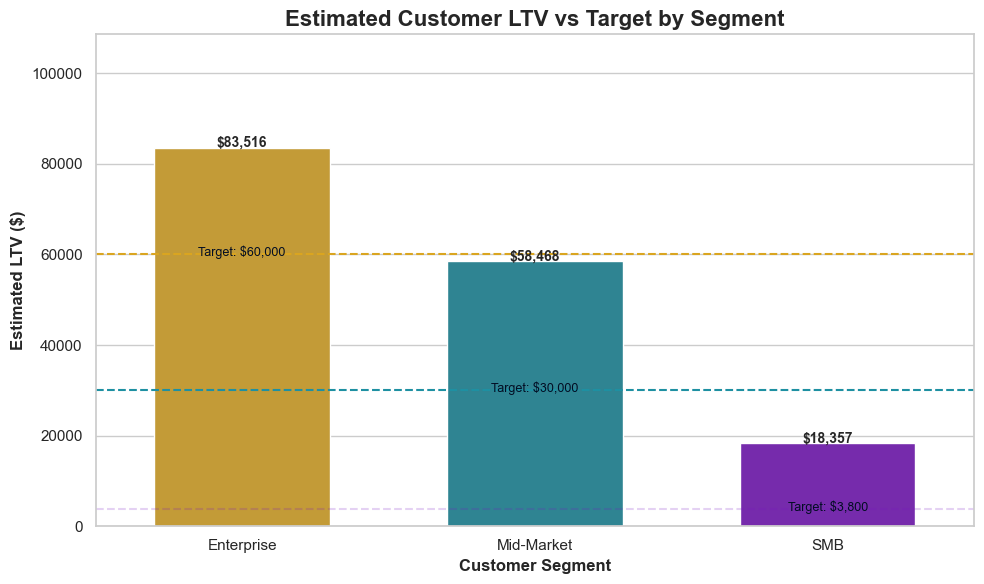

In [8]:
custom_palette = {
    "Enterprise": "#DAA520",    # Goldenrod
    "Mid-Market": "#1E90A2",    # Teal Blue
    "SMB": "#7A15C232"            # Indigo
}

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

bar = sns.barplot(
    data=df,
    x="customer_segment",
    y="estimated_ltv",
    palette=custom_palette,
    width=0.6
)

# Add target line and text annotations
for idx, row in df.iterrows():
    segment = row["customer_segment"]
    color = custom_palette.get(segment, "#333131")

    # Horizontal target line
    bar.axhline(y=row["ltv_target"], linestyle='--', color=color, linewidth=1.5)

    # Estimated LTV label
    bar.text(
        idx, row["estimated_ltv"] + 200,
        f"${int(row['estimated_ltv']):,}",
        ha='center', fontsize=10, fontweight='bold'
    )

    # Target label
    bar.text(
        idx, row["ltv_target"] - 400,
        f"Target: ${int(row['ltv_target']):,}",
        ha='center', fontsize=9, color="#020d23"
    )

# Final plot formatting
plt.title("Estimated Customer LTV vs Target by Segment", fontsize=16, fontweight="bold")
plt.xlabel("Customer Segment", fontsize=12, fontweight="bold")
plt.ylabel("Estimated LTV ($)", fontsize=12, fontweight="bold")
plt.ylim(0, df["estimated_ltv"].max() * 1.3)
plt.tight_layout()

# ================================
# 💾 Save & Show
# ================================

In [9]:
output_path = os.path.join(
    BASE_PATH,
    "05_visuals",
    "02_project_revenue_profit_analysis",
    "hopify_ltv_vs_target_seg.png"
)

plt.savefig(output_path, dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>